In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl

In [10]:
wine = pd.read_csv("./wine_data.csv", usecols= [0, 1, 2])
# wine = wine.iloc[::, :3:]
x = wine.iloc[::, 1::]
y = wine.iloc[::, :1:]
wine

,class_label,alcohol,malic_acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='alcohol', ylabel='Density'>

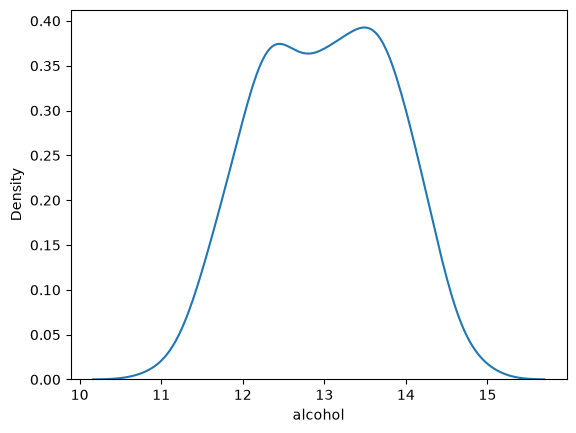

In [11]:
sns.kdeplot(wine["alcohol"])

<Axes: xlabel='malic_acid', ylabel='Density'>

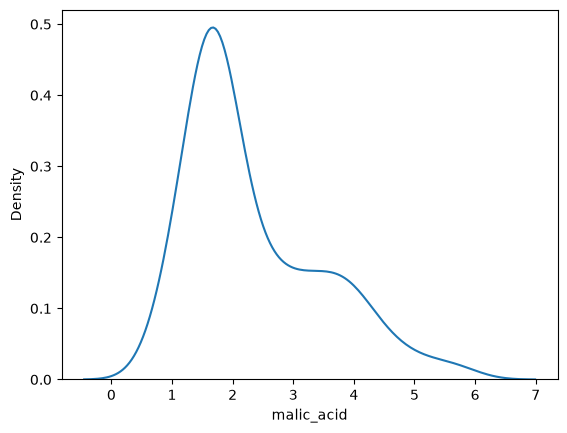

In [12]:
sns.kdeplot(wine["malic_acid"])

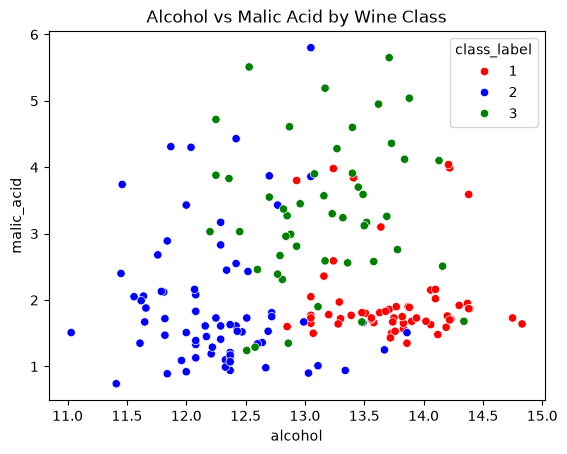

In [38]:
color = {1: "red", 2: "blue", 3: "green"}

sns.scatterplot(data=wine, x="alcohol", y="malic_acid", hue="class_label", palette= color)
plt.title("Alcohol vs Malic Acid by Wine Class")
plt.show()

In [39]:
x_train, x_test, y_train, y_test = skl.model_selection.train_test_split(x, y, test_size=0.3, random_state= 0)

scaler = skl.preprocessing.MinMaxScaler()

scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns, index= x_train.index)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns, index= x_test.index)

In [40]:
np.round(x_train.describe(), 1)

,alcohol,malic_acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


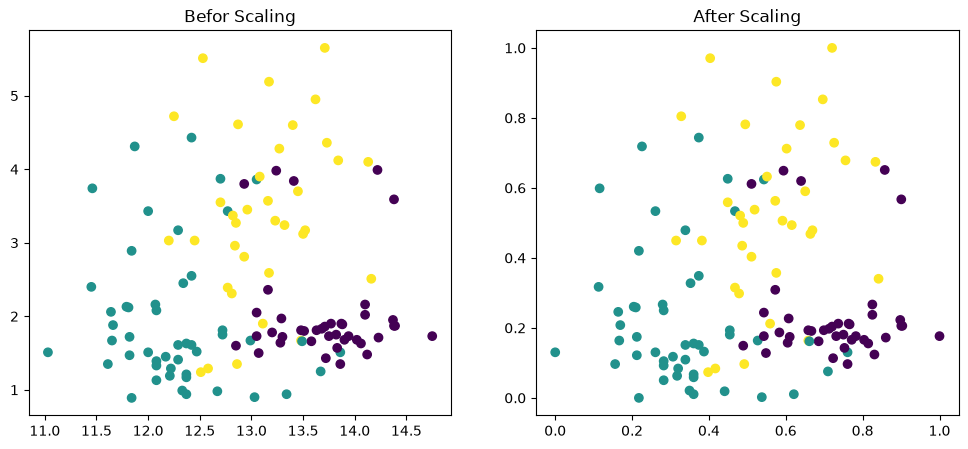

In [48]:
fig, (axis_1, axis_2) = plt.subplots(ncols=2, figsize=(12, 5))

axis_1.scatter(x_train["alcohol"], x_train["malic_acid"], c= y_train["class_label"])
axis_1.set_title("Befor Scaling")

axis_2.scatter(x_train_scaled["alcohol"], x_train_scaled["malic_acid"], c= y_train["class_label"])
axis_2.set_title("After Scaling")

plt.show()

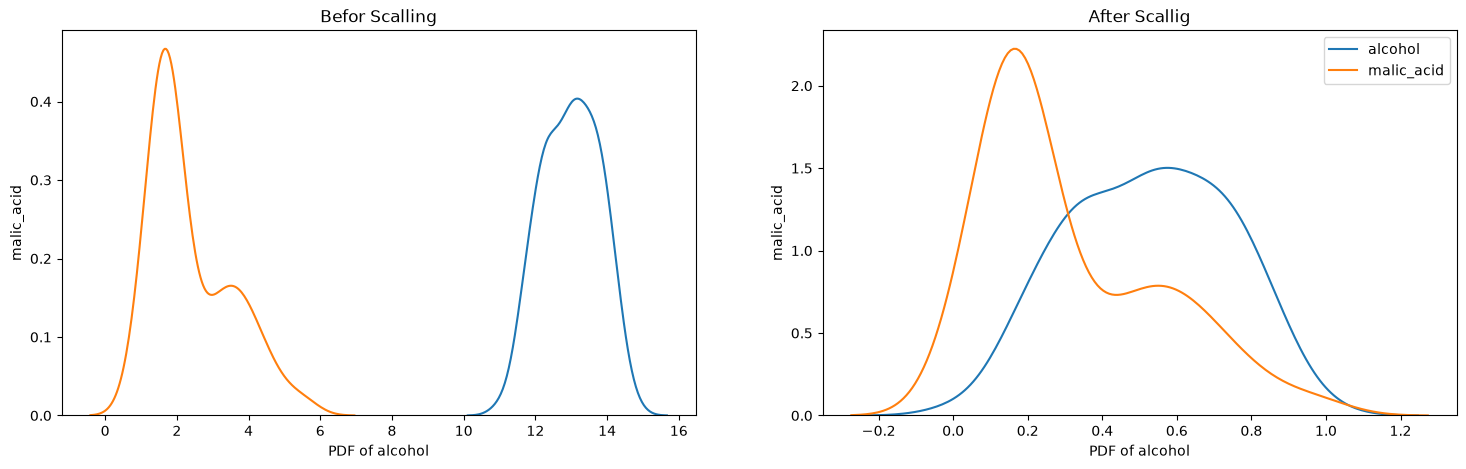

In [49]:
fig, (axis_1, axis_2) = plt.subplots(ncols=2, figsize=(18, 5))

sns.kdeplot(x_train["alcohol"], ax= axis_1)
sns.kdeplot(x_train["malic_acid"], ax= axis_1)
axis_1.set_title("Befor Scalling")
axis_1.set_xlabel("PDF of alcohol")
axis_1.set_ylabel("malic_acid")
plt.legend(["alcohol", "malic_acid"])

sns.kdeplot(x_train_scaled["alcohol"], ax= axis_2)
sns.kdeplot(x_train_scaled["malic_acid"], ax= axis_2)
axis_2.set_title("After Scallig")
axis_2.set_xlabel("PDF of alcohol")
axis_2.set_ylabel("malic_acid")
plt.legend(["alcohol", "malic_acid"])

plt.show()

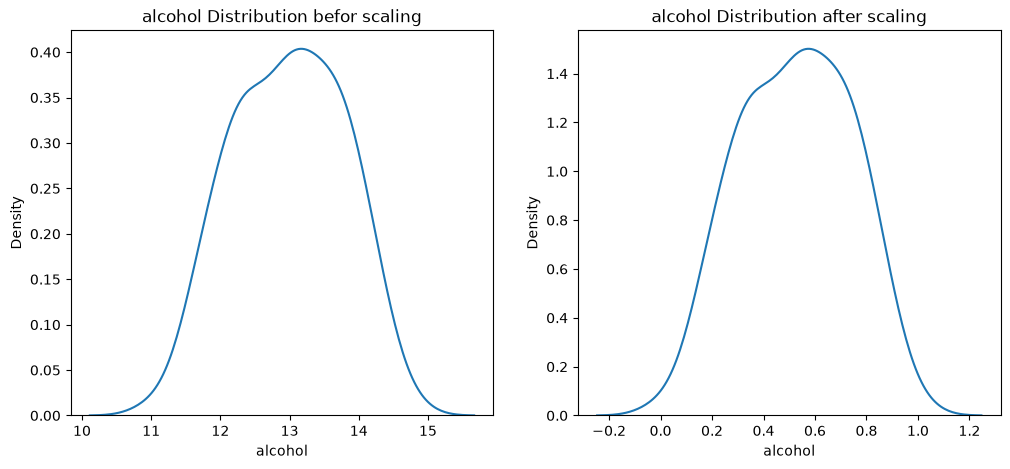

In [50]:
fig, (axis_1, axis_2) = plt.subplots(ncols=2, figsize=(12, 5))

sns.kdeplot(x_train["alcohol"], ax= axis_1)
axis_1.set_title("alcohol Distribution befor scaling")

sns.kdeplot(x_train_scaled["alcohol"], ax= axis_2)
axis_2.set_title("alcohol Distribution after scaling")

plt.show()

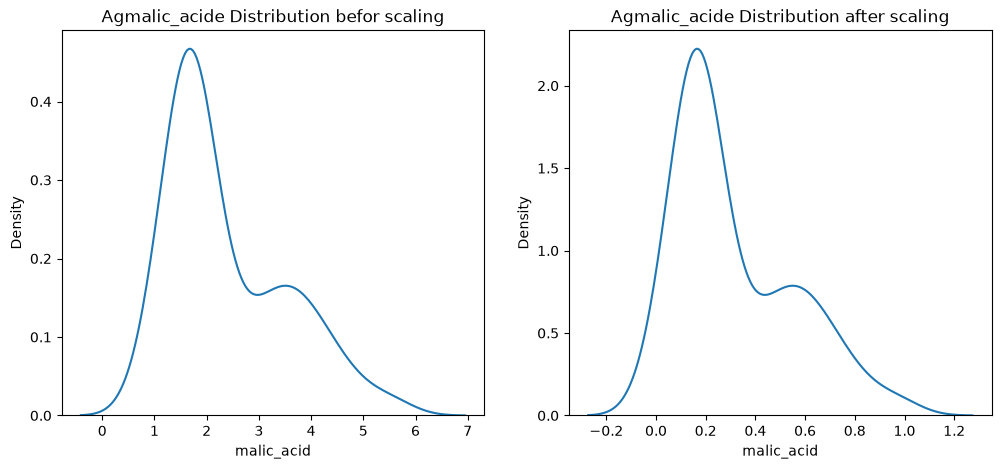

In [51]:
fig, (axis_1, axis_2) = plt.subplots(ncols=2, figsize=(12, 5))

sns.kdeplot(x_train["malic_acid"], ax= axis_1)
axis_1.set_title("Agmalic_acide Distribution befor scaling")

sns.kdeplot(x_train_scaled["malic_acid"], ax= axis_2)
axis_2.set_title("Agmalic_acide Distribution after scaling")

plt.show()